In [1]:
# This is the model that i have build from scratch.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from matplotlib.pylab import copy
import math


In [2]:
df =  pd.read_csv('housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
#Checking for any missing value
df['total_bedrooms'].isnull().sum()
#I think it would be a great idea to fill those gap with median of the other values
df['total_bedrooms'].median()


435.0

In [4]:
df.loc[df['total_bedrooms'].isnull() ,  'total_bedrooms'] = 435
# now we have fill the gap by median 

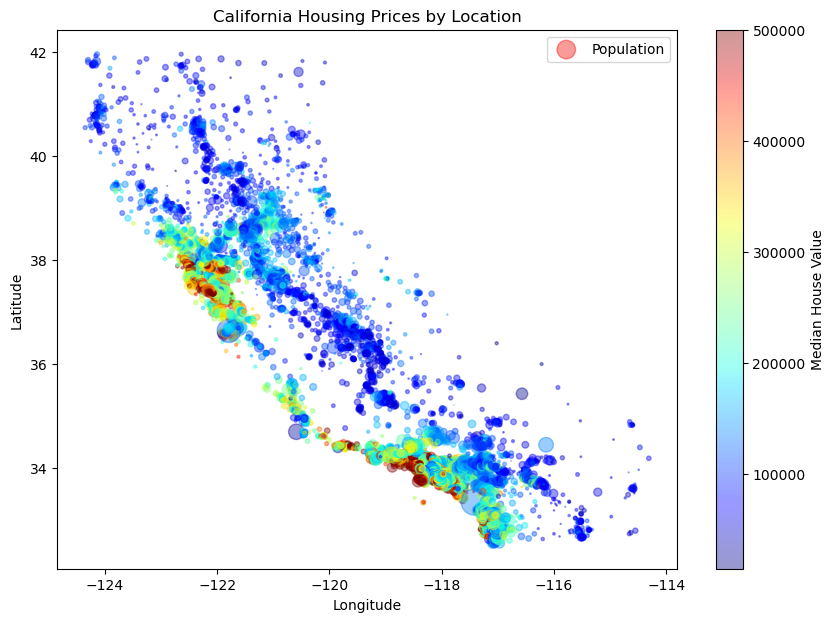

In [5]:
# Let's visualized the giving data set and clean the unwanted noise

plt.figure(figsize=(10, 7))
plt.scatter(df['longitude'], df['latitude'], alpha=0.4,
            s=df['population']/100, label='Population',
            c=df['median_house_value'], cmap='jet')
plt.colorbar(label='Median House Value')


plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('California Housing Prices by Location')
plt.legend()


plt.show() 



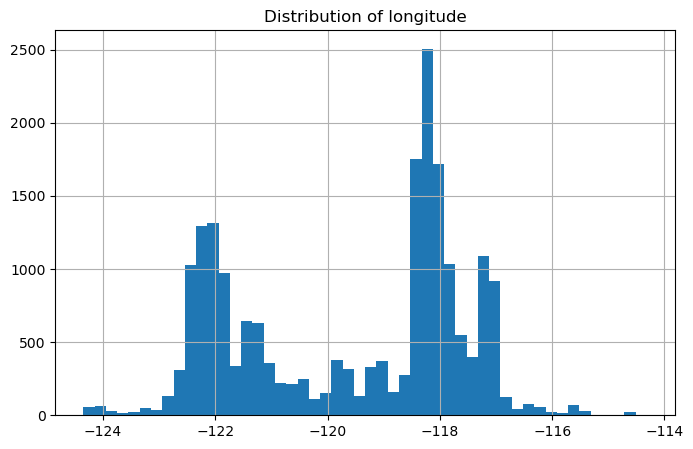

In [6]:
#Histogram for longitude
df['longitude'].hist(bins=50, figsize=(8, 5))
plt.title("Distribution of longitude")
plt.show()

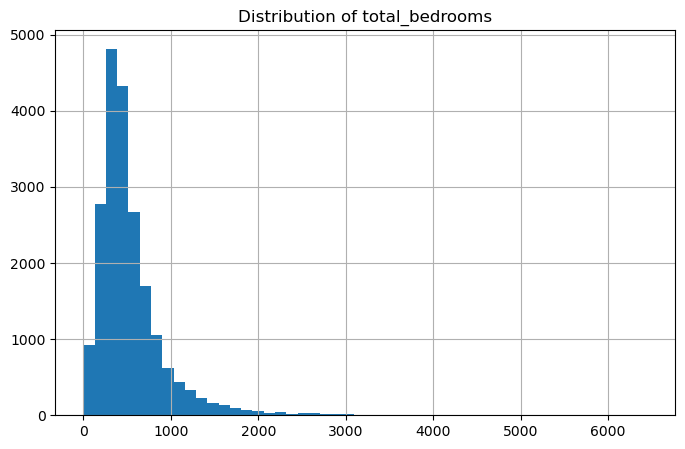

In [7]:
#Histogram for total_bedrooms
df['total_bedrooms'].hist(bins=50, figsize=(8, 5))
plt.title("Distribution of total_bedrooms")
plt.show()

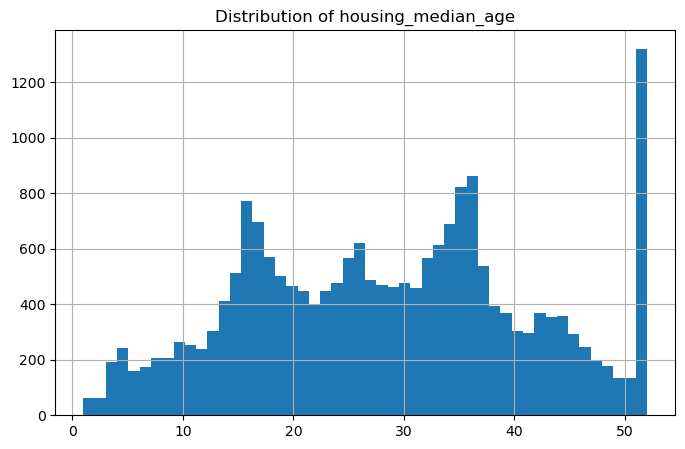

In [8]:
df['housing_median_age'].hist(bins=50, figsize=(8, 5))
plt.title("Distribution of housing_median_age")
plt.show()

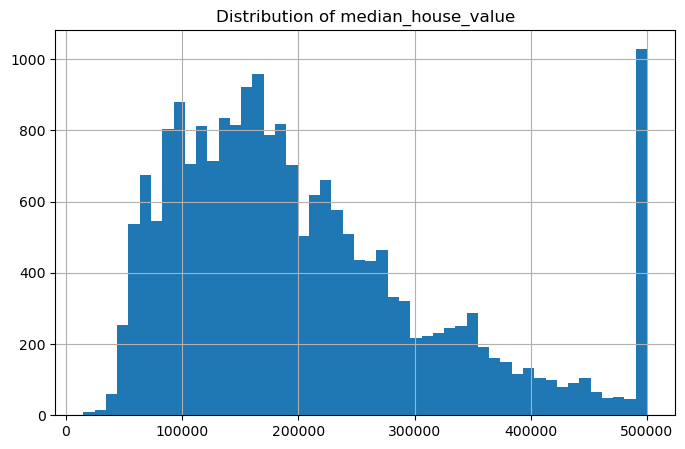

In [9]:
df['median_house_value'].hist(bins=50, figsize=(8, 5))
plt.title("Distribution of median_house_value")
plt.show()

In [10]:
# lets remove the non numerical data set.
# removed the ocean_proximity as it don;t contain any numerical value for  linear regression model 
df = df.drop('ocean_proximity' , axis=1)
# remove the data from median_house_value , housing_median_age as it contain unwanted spike

In [11]:
df = df.drop(df[df['median_house_value'] > 500000].index)

In [12]:
df=df.drop(df[df['housing_median_age'] == 52].index)

In [13]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0
15,-122.26,37.85,50.0,1120.0,283.0,697.0,264.0,2.1250,140000.0
18,-122.26,37.84,50.0,2239.0,455.0,990.0,419.0,1.9911,158700.0
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0


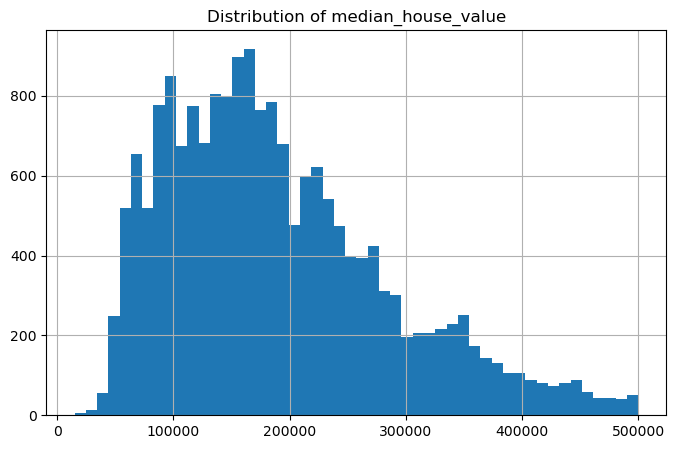

In [14]:
df['median_house_value'].hist(bins=50, figsize=(8, 5))
plt.title("Distribution of median_house_value")
plt.show()

In [15]:
df['Population_per_household'] = df['population']/df['households']



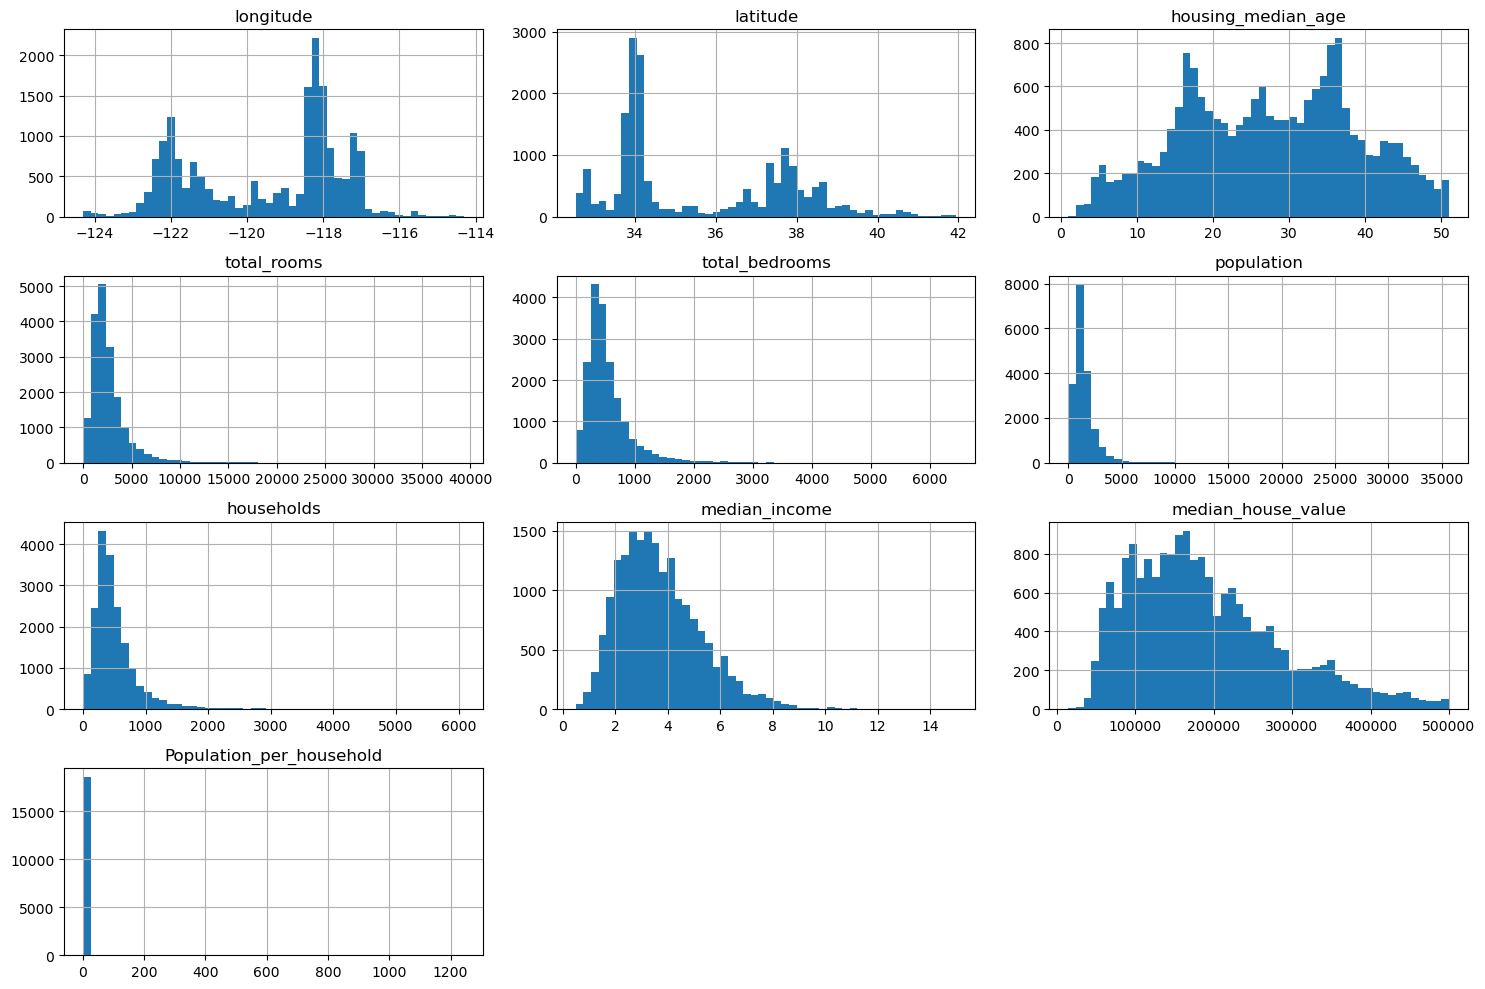

In [16]:
df.hist(bins=50, figsize=(15, 10))

# This layout command stops the titles and axes from squishing together
plt.tight_layout()

# Display the plot
plt.show()

In [17]:
#lets do feature scaling on all the feature except median_house_value as it is a target value.
# I will use Z-Score normalization

feature_column = ["longitude","latitude" , "housing_median_age" ,"total_rooms","total_bedrooms","population","households","median_income","Population_per_household"]
X = df[feature_column]
y = df["median_house_value"]



In [18]:
#splitting the data into 80% training and 20% testing
X_train ,  X_test ,y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=900)

train_mean = X_train.mean()
train_std = X_train.std()

X_train_scaled = (X_train - train_mean)/train_std
X_test_scaled = (X_test - train_mean) / train_std




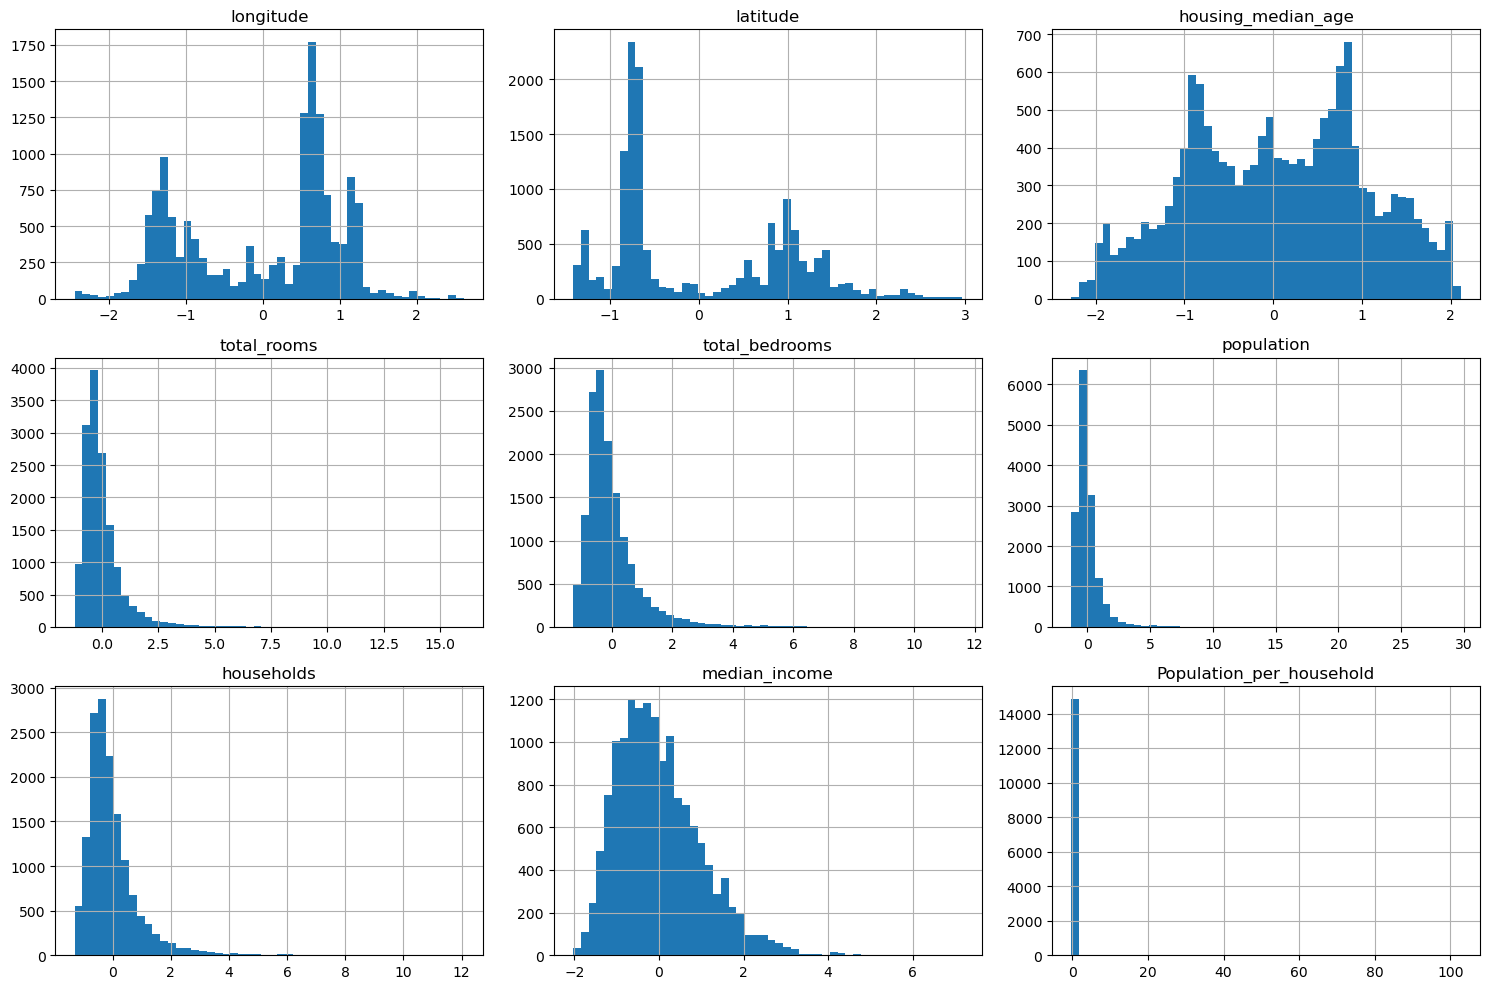

In [19]:
X_train_scaled.hist(bins=50, figsize=(15, 10))

# This layout command stops the titles and axes from squishing together
plt.tight_layout()

# Display the plot
plt.show()

In [20]:
# lets start building algorithm 
X_train_scaled_np = X_train_scaled.to_numpy()
y_train_np = y_train.to_numpy().flatten()

#Initializing weight and baise 
w_init = np.zeros(X.shape[1])
#w.shape = (9,)
b_init = 0.0


iterations = 1500

alpha =  0.1


print(f"Features shape: {X_train_scaled_np.shape}")
print(f"Answers shape:  {y_train_np.shape}")









Features shape: (14857, 9)
Answers shape:  (14857,)


In [21]:
def predict(X_train_scaled_np,y_train_np, w,b):
    f_wb =  np.dot(X_train_scaled_np,w) + b 

    return f_wb

In [22]:
 #computing cost function 
def compute_cost(X_train_scaled_np,y_train_np,w,b):

    m = X_train_scaled_np.shape[0] 

    
    total_cost = 0
    # cost = 0
    # for i in range(m):
    #     f_wb = w*X_train_scaled_np[i] + b

    #     cost += (f_wb - y_train_np[i])**2

    # total_cost = (1/(2*m))*cost

    f_wb = np.dot(X_train_scaled_np,w) + b

    total_cost = (1/(2*m))*(np.sum((f_wb - y_train_np)**2))


    return total_cost

In [23]:
# computing gradient descent to update the weight and biase
def compute_gradient_descent(X_train_scaled_np, y_train_np, w, b):
    m, n = X_train_scaled_np.shape  # (number of examples, number of features)
    dj_dw = np.zeros((n,))
    dj_db = 0.
    
    y_train_np = y_train_np.flatten()
    
    for i in range(m):
        err = (np.dot(X_train_scaled_np[i], w) + b) - y_train_np[i]
        for j in range(n):
            dj_dw[j] = dj_dw[j] + err * X_train_scaled_np[i, j]
        dj_db = dj_db + err
    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_db, dj_dw

In [24]:





def gradient_descent(X_train_scaled_np, y_train_np, w_init, b_init, compute_cost, compute_gradient_descent, alpha, iterations): 
    
    
    # An array to store cost J and w's at each iteration primarily for graphing later
    cost_history = []
    w = w_init.copy() #avoid modifying global w within function
    b = b_init
    
    for i in range(iterations):

        # Calculate the gradient and update the parameters
        dj_db,dj_dw = compute_gradient_descent(X_train_scaled_np, y_train_np, w, b)   

        # Update Parameters using w, b, alpha and gradient
        w = w - alpha * dj_dw               
        b = b - alpha * dj_db               
      
       
        if i<100000:      # prevent resource exhaustion 
            cost_history.append( compute_cost(X_train_scaled_np, y_train_np, w, b))

        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(iterations / 10) == 0:
            print(f"Iteration {i:4d}: Cost {cost_history[-1]:8.2f}   ")
        
    return w, b, cost_history 

In [25]:
print("Starting training...")


final_w, final_b, cost_hist = gradient_descent(
    X_train_scaled_np, 
    y_train_np, 
    w_init, 
    b_init, 
    compute_cost, 
    compute_gradient_descent, 
    alpha, 
    iterations
)

print("\n--- Training Complete! ---")
print(f"Final Bias: {final_b:.2f}")
print(f"Final Weights: {final_w}")


Starting training...
Iteration    0: Cost 18797947237.12   
Iteration  150: Cost 1880341833.54   
Iteration  300: Cost 1834164252.31   
Iteration  450: Cost 1829215400.43   
Iteration  600: Cost 1828486768.47   
Iteration  750: Cost 1828332582.08   
Iteration  900: Cost 1828289250.96   
Iteration 1050: Cost 1828274312.00   
Iteration 1200: Cost 1828268278.21   
Iteration 1350: Cost 1828265540.84   

--- Training Complete! ---
Final Bias: 190030.71
Final Weights: [-75718.71188956 -81552.79781516   8859.01522908 -17429.2819779
  29439.59562073 -35500.14732202  27521.33461884  61071.19811711
    138.44879489]


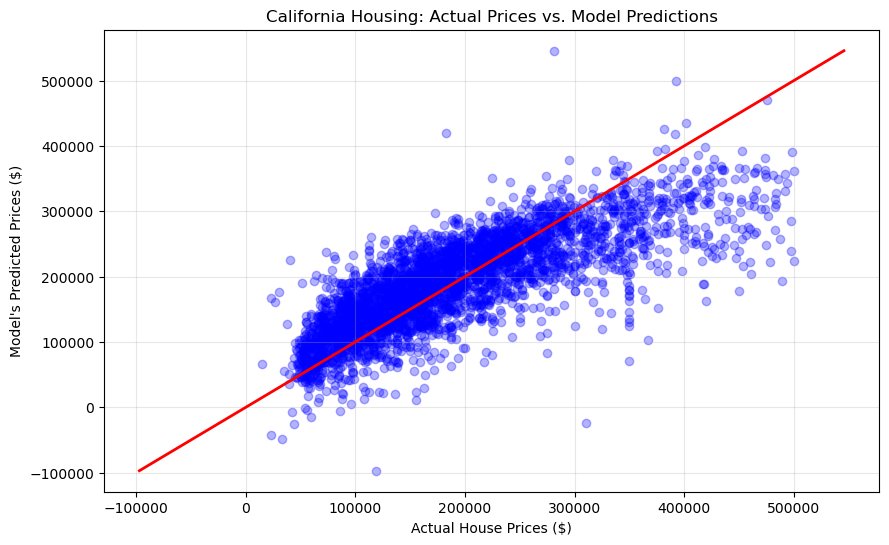

In [26]:
# Prepare test data for prediction
y_test_np = y_test.to_numpy().flatten()
X_test_scaled_np = X_test_scaled.to_numpy()

# Make predictions using the trained model
predictions = np.dot(X_test_scaled_np, final_w) + final_b


plt.figure(figsize=(10, 6))


plt.scatter(y_test_np, predictions, alpha=0.3, color='blue')


max_price = max(y_test_np.max(), predictions.max())
min_price = min(y_test_np.min(), predictions.min())


plt.plot([min_price, max_price], [min_price, max_price], color='red', linewidth=2)


plt.title("California Housing: Actual Prices vs. Model Predictions")
plt.xlabel("Actual House Prices ($)")
plt.ylabel("Model's Predicted Prices ($)")


plt.grid(True, alpha=0.3)
plt.show()

In [27]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np


r2 = r2_score(y_test_np, predictions)

rmse = np.sqrt(mean_squared_error(y_test_np, predictions))

print("--- Final Model Report Card ---")
print(f"R-squared Score:  {r2 * 100:.2f}%")
print(f"Average Error:    ${rmse:,.2f} off per house")

--- Final Model Report Card ---
R-squared Score:  61.46%
Average Error:    $58,919.81 off per house
